# Taak 3

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np # For working with multidimensional array and matrix data structures.
import matplotlib.pyplot as plt # Used for ploting graphs.

# Doen self

U sal gevra word om K-gemiddeldes en GMM self te implementeer in hierdie afdeling.

## Genereer lukrake date

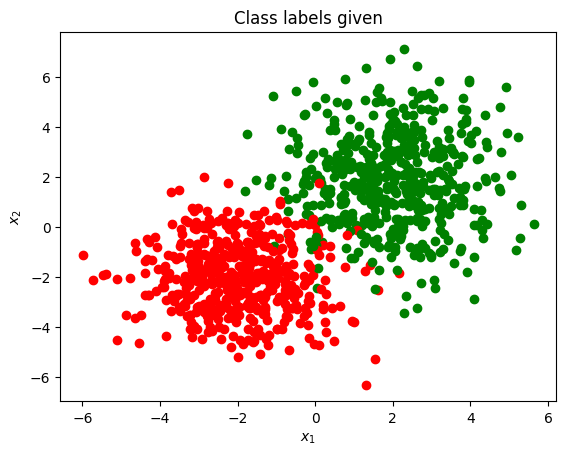

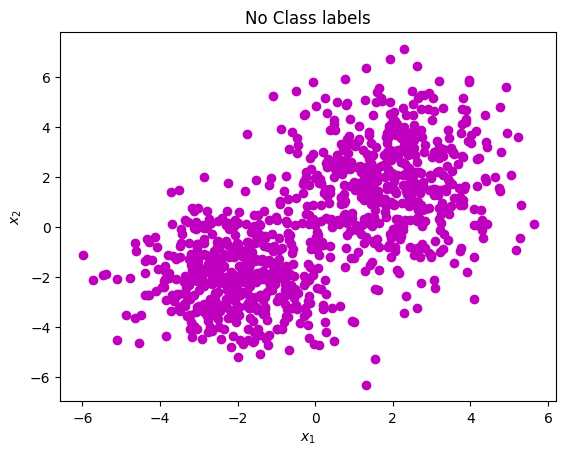

In [3]:
# Training data - two randomly-generated Gaussian-distributed clouds of points in 2d space
np.random.seed(0)
# Number of points
N = 1000
# Labels for each cluster
y = np.random.randint(low=0, high=2, size = N)
c = np.array(["r","g"])
# Mean of each cluster
means = np.array([[-2, 2], [-2, 2],])
# Covariance (in X and Y direction) of each cluster
covariances = np.random.random_sample((2, 2)) + 1
# Dimensions of each point
X = np.vstack([np.random.randn(N)*covariances[0, y] + means[0, y],
               np.random.randn(N)*covariances[1, y] + means[1, y]])

for k in range(X.shape[1]):
    plt.plot(X[0,k],X[1,k],c[y[k]]+"o")
    
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Class labels given")
plt.show()

for k in range(X.shape[1]):
    plt.plot(X[0,k],X[1,k],"m"+"o")
    
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("No Class labels")
plt.show()

# Plot the data

## K-gemiddeldes

**Skryf asb. 'n generiese python funksie (in 'n aparte pakket) wat 'n generiese weergawe van die K-gemiddeldes algoritme implementeer. U funksie moet as toevoer 'n $d$-dimensionele datastel en die aantal trosse waarin u die datastel wil groepeer. Keer die gemiddeldes van u K-trosse en die toegekende etikette van u datastel terug (gebruik 1-van-K kodering om u etikette te verteenwoordig). Initialiseer u gemiddeldes met twee lukrake waarnemings.**

In [4]:
from IPython.display import HTML
from IPython.display import display
from IPython.display import Image

**Gebruik u nuutgeskepte funksie om etikette toe te ken aan die lukrake datastel wat ons hierbo gegenereer het. Plot die data en hulle nuut toegekende etikette. Plot ook die gemiddelde van die twee trosse. U gegenereerde plot behoort soos volg te lyk:**

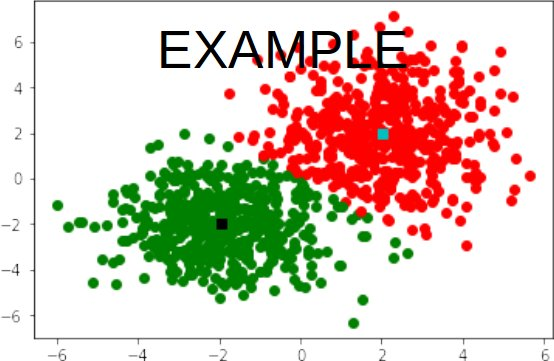

In [5]:
display(Image(filename='./kmeans.jpg'))

$x_1$ is op die $x$-as en $x_2$ is op die $y$-as.

# Voer K-gemiddeldes op 'n beeld uit

In [6]:
from skimage import io  # for loading an image from a file.
from sklearn.datasets import load_sample_image # imports available image from sklean dataset

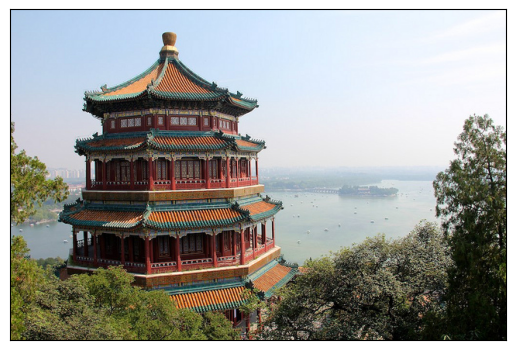

In [7]:
china = load_sample_image("china.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(china);

In [8]:
# Reshape the image

In [9]:
data = china / 255.0 # use 0...1 scale
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

# Visualiseer moontlike kleure van die beeld, deur 'n k-gemiddeldes trosvorming oor die beeldelementruimte te gebruik


In [10]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    
    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

 Die  MiniBatchKmeans is 'n wysiging van die KMeans algoritme wat mini-bondels gebruik om die berekeningstyd te verminder, eerder as om die volle datastel op elke iterasie te gebruik, terwyl mens nogtans dieselfde teikenfunksie probeer optimeer.
 Mini-bondels is subversamelings van die toevoerdata, lukraak gekies in elke afrigiterasie.
Hierdie vermeerder die spoed van die algoritme, tipies met 'n faktor van 3-4.   Veral belangrik, dit maak dit moontlik om trosvorming toe te pas op baie groot datastelle wat nie in die geheue inpas.

Kleurkwantisering is die proses om die aantal kleure in 'n beeld te verminder terwyl die visuele voorkoms van die beeld behou word.
Hierdie is 'n nuttige beeldsaampersingtegniek wat nogal nuttig is vir toestelle wat slegs 'n beperkte aantal kleure kan vertoon a.g.v. geheuebeperkings.

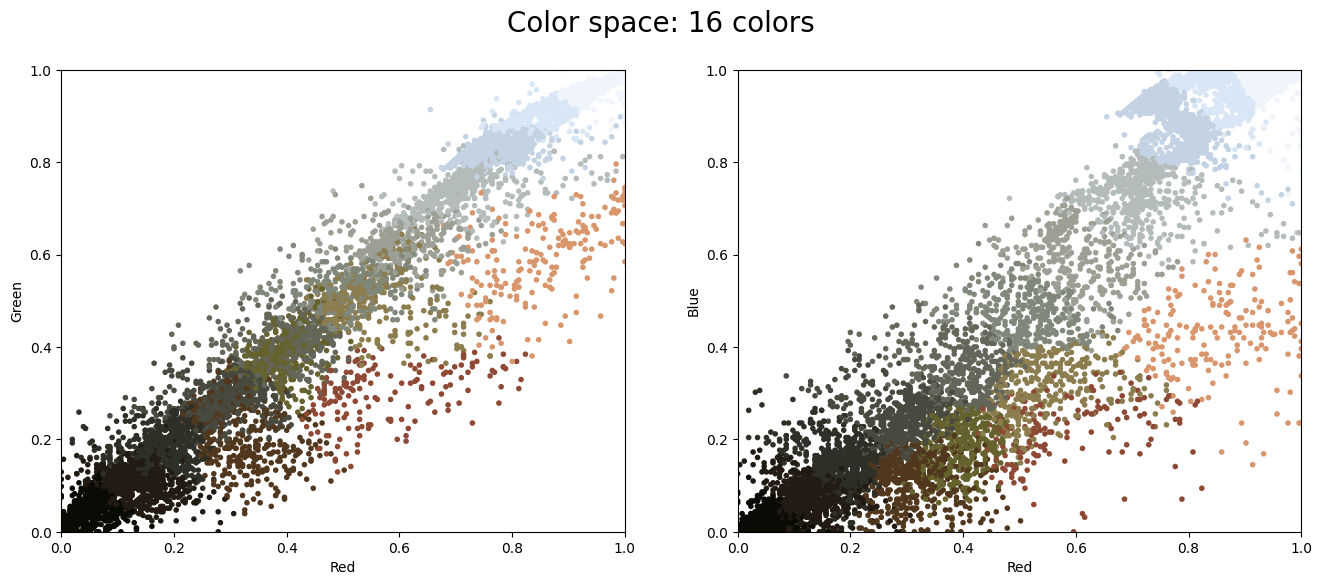

In [11]:
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Color space: 16 colors")

In [12]:
from ipywidgets import interact, interactive, fixed, interact_manual, IntSlider # for interactive slider

**Skep asb. 'n wiggiefunksie met die ipywidgets biblioteek van python wat alreeds hierbo ingevoer is, en pas dit toe op die beeld (china) hierbo. U funksie moet K (die aantal trosse) as toevoer neem deur die verstekskuiwer. Wenk: Lees die dokumentasie oor ipywidgets. As mens die beeld herskep met net 3 kleure kry mens iets soos die volgende beeld.** 

**Hoeveel trosse het u nodig om die beeld perfek te herskep?**

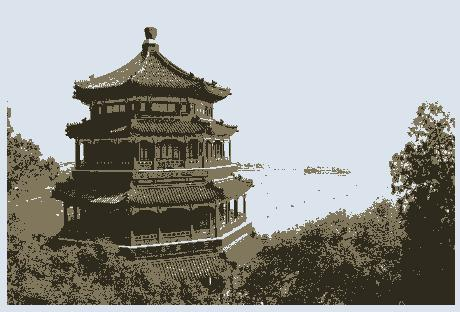

In [13]:
display(Image(filename='./Compressed.jpg'))

## GMM

**Skryf asb. 'n generiese python funksie (in 'n aparte pakket) wat 'n generiese weergawe van die Gaussiese mengselmodel algoritme implementeer. U funksie moet as toevoer 'n $d$-dimensionele datastel neem, asook die aantal trosse waarin u u datastel wil groepeer. Keer terug die aantal lede, die gemiddeldes en kovariansies van u K trosse terug.  Keer ook die verantwoordelikhede van u waarnemings (vir elke waarneming in u datastel).  Gebruik u K-gemiddelde funksie om u GMM te initialiseer.**

**Gebruik u nuutgeskepte funksie om trosvorming toe te pas op die datastel gegenereer aan die begin van die K-gemiddeldes afdeling.  Plot die 95% vertrouensinterval van u data en gebruik die verantwoordelikheid van elke data punt om die kleur vir elke waarneming te stel.  U gegenereerde plot behoort soos volg te lyk:**

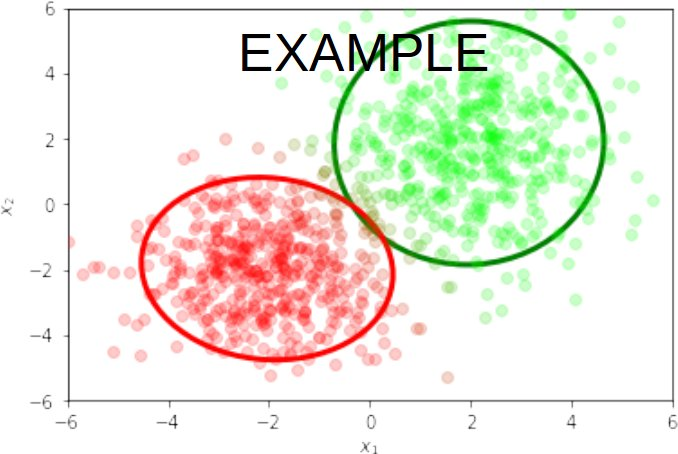

In [14]:
display(Image(filename='./gmm.jpg'))

# Trosvorming van syferdata met GMM

Vir die volgende probleem sal u GMM (scikit-learn weergawe) gebruik om trosvorming toe te pas op die syferdata in die scikit-learn biblioteek.

## Laai die syfer datastelle

Die datastelle word gelaai in 'n assosiatiewe skikking.

In [15]:
# Import `datasets` from `sklearn`
from sklearn import datasets

# Load in the `digits` data
digits = datasets.load_digits()
print(digits.keys())

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [16]:
# Find the number of unique labels
number_digits = len(np.unique(digits.target))

print (number_digits)

10


## Ondersoek die verskillende syferbeelde

In [17]:
import matplotlib.cm as cm # helps you work with grayscale images

In [18]:
def show_digits(k=0):
    """
    Show the digits in the training set
    """
    
    plt.imshow(digits.images[k], cmap=cm.binary)   
    
    plt.show()
    
w_show_digits = interact(show_digits, k =(0, 1796)) 


interactive(children=(IntSlider(value=0, description='k', max=1796), Output()), _dom_classes=('widget-interact…


**Pas volgende die data op 'n 10-komponent GMM model, met gebruik van die scikit-learn pakket.**

**Nadat u die GMM model gebou het, onttrek die gemiddeldes en kovariansies van die 10 GMM komponente. Vertoon die gemiddeldes om iets soos die beeld hieronder te kry.**

In [19]:
data = digits.data

np.random.seed(1)
# Insert GMM code

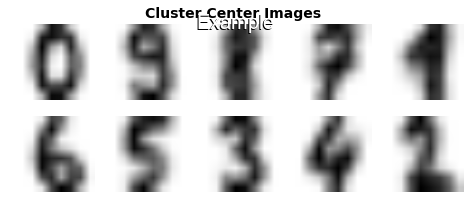

In [20]:
display(Image(filename='./wm_GMM.png'))

## Genereer waarnemings

**Gebruik die gemiddeldes en kovariansies van die verskillende komponente en trek 'n waarneming van elke komponent.  Vertoon die waarnemings in 'n beeld.**

*Wenk*: Lees die dokumentasie van scipy.stats.multivariate_normal

**Nou kan u probeer om die kleurkwantifisering- en syferanalises met u nuutgeskepte toepassings van k-gemiddeldes en GMM onderskeidelik, en sien of u dieselfde afvoere kry.**